# Telecom X - Análisis de Evasión de Clientes Parte II

##🏢 Contexto del Problema

La mision es desarrollar modelos predictivos capaces de prever qué clientes tienen mayor probabilidad de cancelar sus servicios.

La empresa quiere anticiparse al problema de la cancelación, y nos corresponde  construir un pipeline robusto para esta etapa inicial de modelado.

🧠**Objetivos del Desafío**

Preparar los datos para el modelado (tratamiento, codificación, normalización).

Realizar análisis de correlación y selección de variables.

Entrenar dos o más modelos de clasificación.

Evaluar el rendimiento de los modelos con métricas.

Interpretar los resultados, incluyendo la importancia de las variables.

Crear una conclusión estratégica señalando los principales factores que influyen en la cancelación.






## 📚 Bibliotecas y librerias

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

##📌 Extracción

Carga el archivo CSV que contiene los datos tratados anteriormente.

In [2]:
import pandas as pd

df = pd.read_csv('/content/telecom_churn_limpio.csv')
pd.set_option('display.max_columns', None)

df.head()

,customerid,churn,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,charges_monthly,charges_total,tenure_group
0,0002-ORFBO,0,0,0,1,1,9,1,0,DSL,0,1,0,1,1,0,One year,1,Mailed check,65.6,593.30,6-12
1,0003-MKNFE,0,1,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,6-12
2,0004-TLHLJ,1,1,0,0,0,4,1,0,Fiber optic,0,0,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,0-6
3,0011-IGKFF,1,1,1,1,0,13,1,0,Fiber optic,0,1,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,12-24
4,0013-EXCHZ,1,0,1,1,0,3,1,0,Fiber optic,0,0,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,0-6


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   object 
 1   churn             7043 non-null   int64  
 2   gender            7043 non-null   int64  
 3   seniorcitizen     7043 non-null   int64  
 4   partner           7043 non-null   int64  
 5   dependents        7043 non-null   int64  
 6   tenure            7043 non-null   int64  
 7   phoneservice      7043 non-null   int64  
 8   multiplelines     7043 non-null   int64  
 9   internetservice   7043 non-null   object 
 10  onlinesecurity    7043 non-null   int64  
 11  onlinebackup      7043 non-null   int64  
 12  deviceprotection  7043 non-null   int64  
 13  techsupport       7043 non-null   int64  
 14  streamingtv       7043 non-null   int64  
 15  streamingmovies   7043 non-null   int64  
 16  contract          7043 non-null   object 


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
churn,7043.0,0.265370,0.441561,0.00,0.00,0.00,1.00,1.00
gender,7043.0,0.504756,0.500013,0.00,0.00,1.00,1.00,1.00
seniorcitizen,7043.0,0.162147,0.368612,0.00,0.00,0.00,0.00,1.00
partner,7043.0,0.483033,0.499748,0.00,0.00,0.00,1.00,1.00
dependents,7043.0,0.299588,0.458110,0.00,0.00,0.00,1.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
phoneservice,7043.0,0.903166,0.295752,0.00,1.00,1.00,1.00,1.00
multiplelines,7043.0,0.421837,0.493888,0.00,0.00,0.00,1.00,1.00
onlinesecurity,7043.0,0.286668,0.452237,0.00,0.00,0.00,1.00,1.00
onlinebackup,7043.0,0.344881,0.475363,0.00,0.00,0.00,1.00,1.00


In [5]:
display(df.describe(include='object'))

,customerid,internetservice,contract,paymentmethod,tenure_group
count,7043,7043,7043,7043,7043
unique,7043,3,3,4,5
top,9995-HOTOH,Fiber optic,Month-to-month,Electronic check,48+
freq,1,3096,3875,2365,2239


In [6]:
df.dtypes

,0
customerid,object
churn,int64
gender,int64
seniorcitizen,int64
partner,int64
dependents,int64
tenure,int64
phoneservice,int64
multiplelines,int64
internetservice,object


## Eliminacion de columnas


Eliminamos 'customerid' porque es solo un identificador único y no aporta información predictiva al modelo. También eliminamos 'tenure_group' porque contiene información derivada de 'tenure', lo que podría introducir
redundancia en el modelo (duplicación de información)

In [7]:
df = df.drop(["customerid", "tenure_group"], axis=1)

In [8]:
df.columns

Index(['churn', 'gender', 'seniorcitizen', 'partner', 'dependents', 'tenure',
       'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity',
       'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv',
       'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod',
       'charges_monthly', 'charges_total'],
      dtype='object')

## Feature Engineering

crearemos 2 nuevas variables

Creamos una variable que representa el gasto promedio mensual del cliente durante su permanencia en la empresa. Esto permite capturar el comportamiento histórico de gasto del cliente, complementando la variable 'charges_monthly', que solo refleja el cargo actual.

In [9]:
df["avg_monthly_spend"] = df["charges_total"] / (df["tenure"] + 1)

In [10]:
df[["charges_monthly", "avg_monthly_spend"]].corr()

,charges_monthly,avg_monthly_spend
charges_monthly,1.000000,0.956003
avg_monthly_spend,0.956003,1.000000


Existe una alta correlación entre charges_monthly y avg_monthly_spend (0.95), lo que indica que ambas variables contienen información muy similar. Para evitar redundancia y posibles problemas de multicolinealidad, se conserva únicamente charges_monthly, ya que representa el costo actual del servicio, variable que puede influir directamente en la decisión de churn.

In [11]:
df = df.drop(columns=['avg_monthly_spend'])

___________________
Creamos una variable que contabiliza el número total de servicios adicionales contratados por cada cliente. La hipótesis es que clientes con más servicios tienden a tener mayor compromiso con la empresa y, por lo tanto, menor probabilidad de cancelar el servicio.

In [12]:
services = [
    "onlinesecurity",
    "onlinebackup",
    "deviceprotection",
    "techsupport",
    "streamingtv",
    "streamingmovies"
]

df["num_services"] = df[services].sum(axis=1)

## Encoding

In [13]:
# Separamos el target del resto de variables
X = df.drop('churn', axis=1)
y = df['churn']

In [14]:
# Seleccionamos las variables Categoricas
categorical_cols = ['internetservice', 'contract', 'paymentmethod']

In [15]:
# Utilizaremos OneHotEncoder
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', # Evita la multicolinealidad
                        sparse_output=False) # Devuelve un array normal y no una matriz dispersa
X_encoded = encoder.fit_transform(X[categorical_cols])

In [16]:
# Recuperamos los nombres de las columnas
encoded_cols = encoder.get_feature_names_out(categorical_cols)

# Convertimos a DF
X_encoded_df = pd.DataFrame(X_encoded, columns=encoded_cols, index=X.index)

# Eliminamos las columnas originales y finalmente unimos
X = X.drop(columns=categorical_cols)
X = pd.concat([X, X_encoded_df], axis=1)

In [17]:
X.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,paperlessbilling,charges_monthly,charges_total,num_services,internetservice_Fiber optic,internetservice_No,contract_One year,contract_Two year,paymentmethod_Credit card (automatic),paymentmethod_Electronic check,paymentmethod_Mailed check
0,0,0,1,1,9,1,0,0,1,0,1,1,0,1,65.6,593.30,3,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,1,0,0,0,9,1,1,0,0,0,0,0,1,0,59.9,542.40,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1,0,0,0,4,1,0,0,0,1,0,0,0,1,73.9,280.85,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1,1,1,0,13,1,0,0,1,1,0,1,1,1,98.0,1237.85,4,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0,1,1,0,3,1,0,0,0,0,1,1,0,1,83.9,267.40,2,1.0,0.0,0.0,0.0,0.0,0.0,1.0


## Balanceo


observaremos que tan desbalanceado esta nuestra variable *churn* y si es necesario balancearla mediante algun método

In [18]:
y.value_counts()

,count
churn,
0,5174
1,1869


In [19]:
y.value_counts(normalize=True)

,proportion
churn,
0,0.73463
1,0.26537


Se verificó la distribución de la variable objetivo *churn*. Los resultados muestran que aproximadamente el 73% de los clientes permanecen activos, mientras que el 27% han cancelado el servicio. Esto indica un desbalance moderado entre las clases, lo cual puede influir en el desempeño de algunos modelos predictivos al favorecer la clase mayoritaria

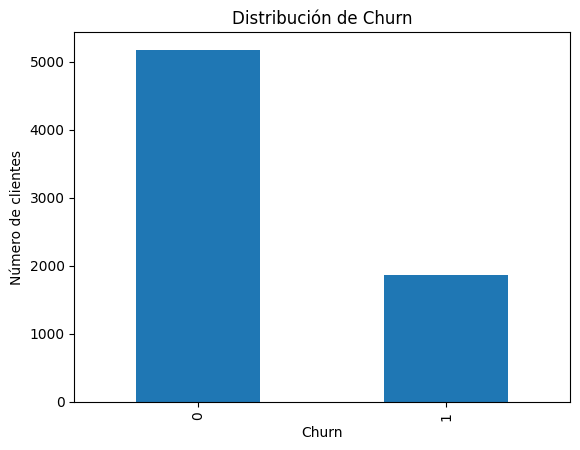

In [20]:
y.value_counts().plot(kind="bar")
plt.title("Distribución de Churn")
plt.xlabel("Churn")
plt.ylabel("Número de clientes")
plt.show()

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# crear modelo
log_model = LogisticRegression(max_iter=1000)

# entrenar
log_model.fit(X_train, y_train)

# predicciones
y_pred = log_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [23]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7899219304471257

Confusion Matrix:
[[918 117]
 [179 195]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.62      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [24]:
!pip install imbalanced-learn

In [25]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [26]:
print("Antes:")
print(y_train.value_counts())

print("\nDespués de SMOTE:")
print(y_train_smote.value_counts())

Antes:
churn
0    4139
1    1495
Name: count, dtype: int64

Después de SMOTE:
churn
0    4139
1    4139
Name: count, dtype: int64


In [27]:
log_model_smote = LogisticRegression(max_iter=1000)

log_model_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = log_model_smote.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [28]:
print("Accuracy con SMOTE:", accuracy_score(y_test, y_pred_smote))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_smote))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote))

Accuracy con SMOTE: 0.7814052519517388

Confusion Matrix:
[[845 190]
 [118 256]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.82      0.85      1035
           1       0.57      0.68      0.62       374

    accuracy                           0.78      1409
   macro avg       0.73      0.75      0.74      1409
weighted avg       0.80      0.78      0.79      1409



Se entrenó un modelo base utilizando los datos originales y posteriormente se aplicó SMOTE para balancear la clase minoritaria. Al comparar los resultados, se observó que el modelo balanceado mejoró el recall de la clase churn, lo que permite detectar una mayor proporción de clientes con riesgo de cancelación

## Normalizacion

Vamos a normalizar nuestros datos balanceados debido a que usaremos tecnicas que no funcionaran bien se omitimos este paso

In [29]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

## Analisis de correlacion

In [30]:
y_train = y_train.rename('churn')
df_combined = pd.concat([X_train, y_train], axis=1)


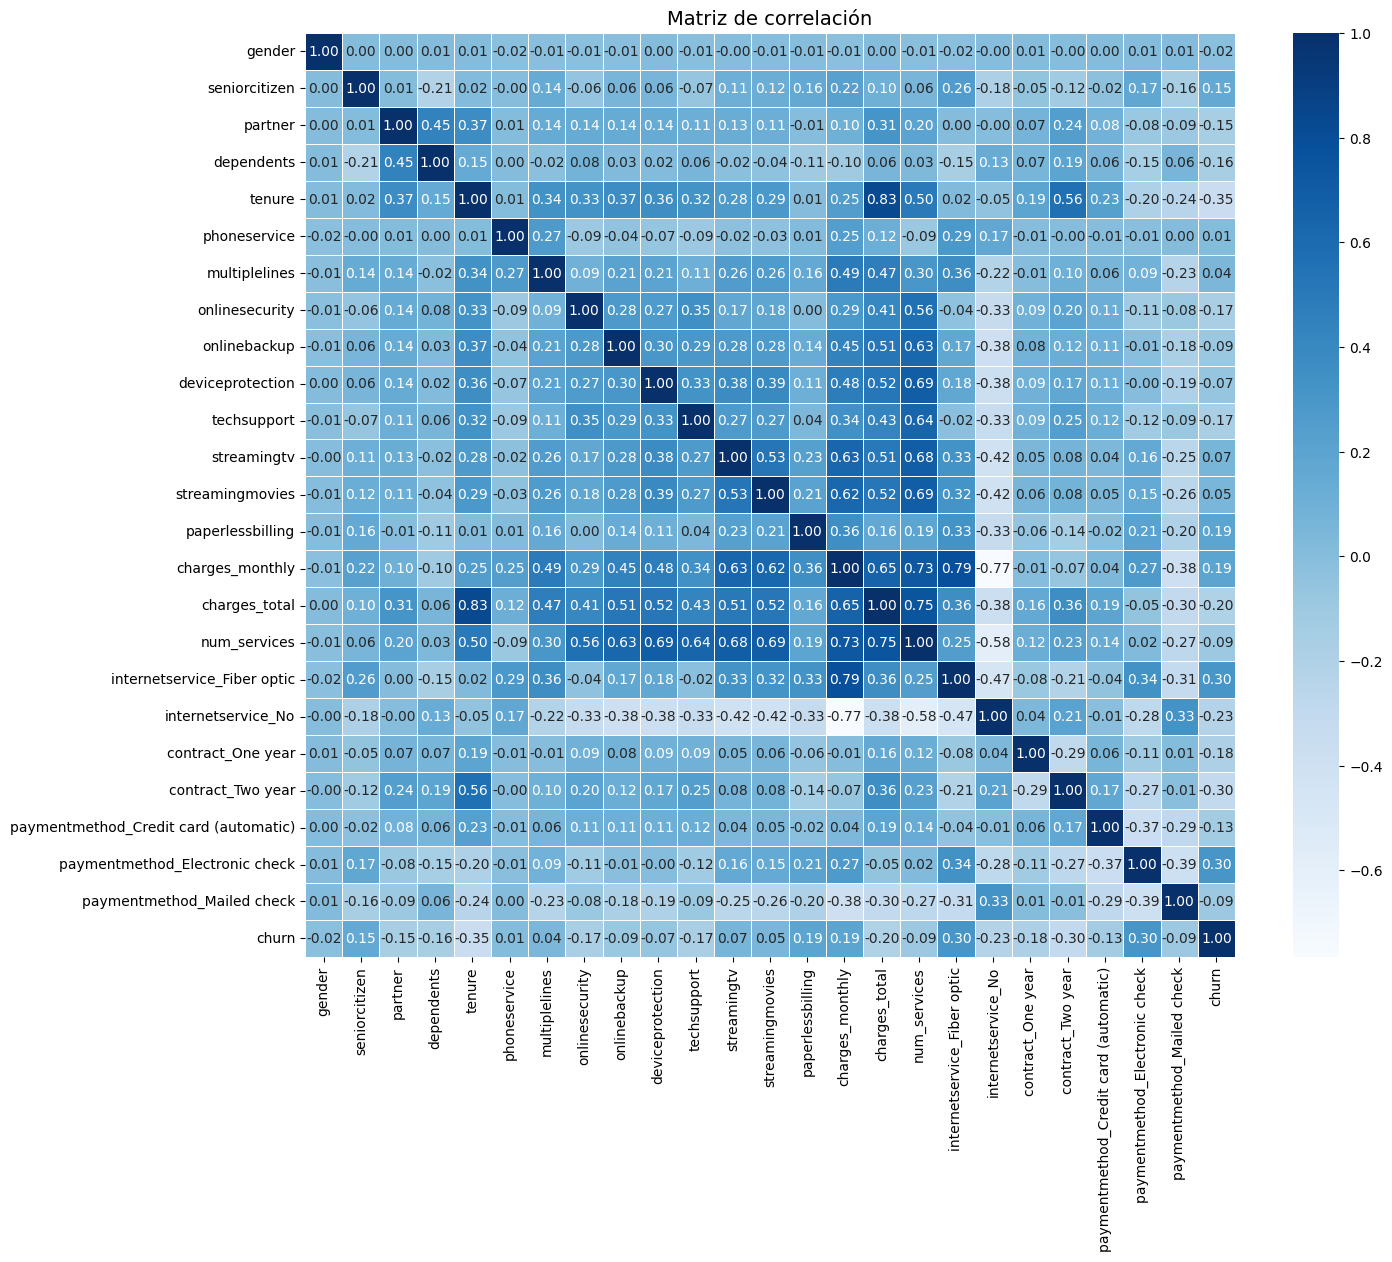

In [31]:
# Seleccionar solo variables numéricas
numeric_df = df_combined.select_dtypes(include=["int64", "float64"])

# Matriz de correlación
corr_matrix = numeric_df.corr()

plt.figure(figsize=(15,12))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriz de correlación", fontsize=14)
plt.show()

Se observa que variables como **paymentmethod_Electronic check**, **internetservice_Fiber optic** y **charges_monthly** presentan correlación positiva con churn, lo que indica que los clientes con estas características tienen mayor probabilidad de cancelar el servicio.

Por otro lado, variables como **tenure**, **contract_Two year** y **charges_total** muestran correlación negativa con churn, sugiriendo que los clientes con mayor antigüedad, contratos más largos o mayor gasto acumulado tienden a permanecer en la empresa.



In [32]:
corr_matrix["churn"].sort_values(ascending=False)

,churn
churn,1.000000
paymentmethod_Electronic check,0.304426
internetservice_Fiber optic,0.303902
paperlessbilling,0.192693
charges_monthly,0.188884
seniorcitizen,0.153134
streamingtv,0.067602
streamingmovies,0.051428
multiplelines,0.042973
phoneservice,0.008782


Podemos observar 2 cosas aqui:



*   Los clientes con internet de fibra óptica, pagos electrónicos y mayores cargos mensuales presentan una mayor tendencia a cancelar el servicio.

*   Los clientes con mayor antigüedad, contratos a largo plazo y mayor gasto acumulado presentan menor probabilidad de cancelar el servicio



## Analisis dirigido

### Tiempo de contrato vs cancelación

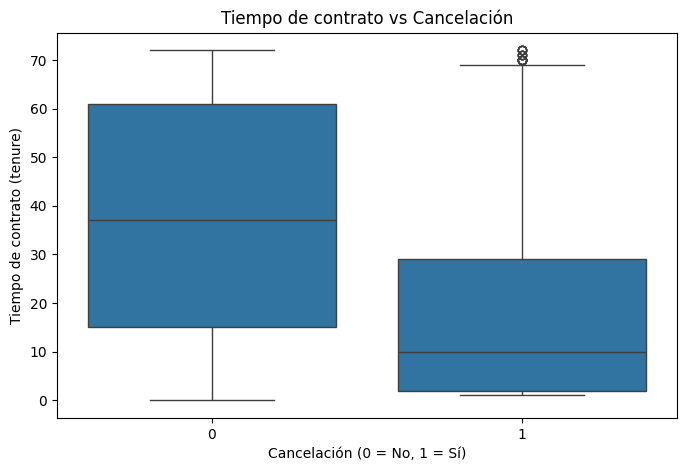

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="churn",
    y="tenure",
    data=df_combined
)

plt.title("Tiempo de contrato vs Cancelación")
plt.xlabel("Cancelación (0 = No, 1 = Sí)")
plt.ylabel("Tiempo de contrato (tenure)")

plt.show()

### Gasto total vs cancelación

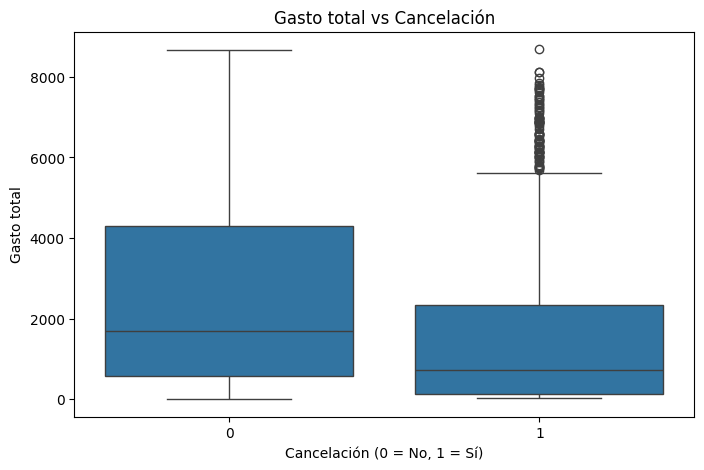

In [34]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="churn",
    y="charges_total",
    data=df_combined
)

plt.title("Gasto total vs Cancelación")
plt.xlabel("Cancelación (0 = No, 1 = Sí)")
plt.ylabel("Gasto total")

plt.show()

### Gasto mensual vs cancelación

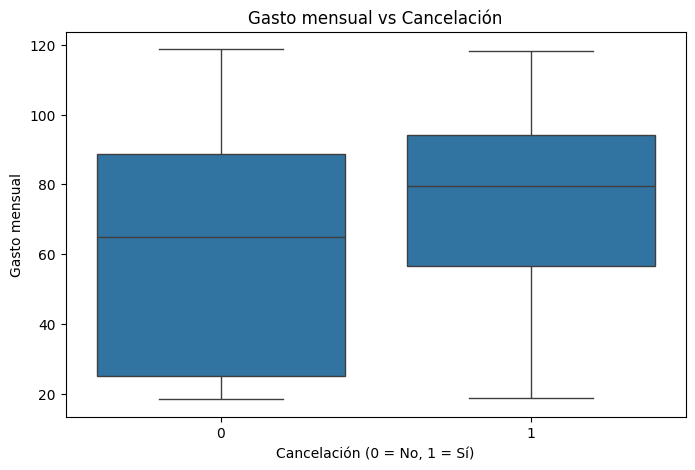

In [35]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="churn",
    y="charges_monthly",
    data=df_combined
)

plt.title("Gasto mensual vs Cancelación")
plt.xlabel("Cancelación (0 = No, 1 = Sí)")
plt.ylabel("Gasto mensual")

plt.show()

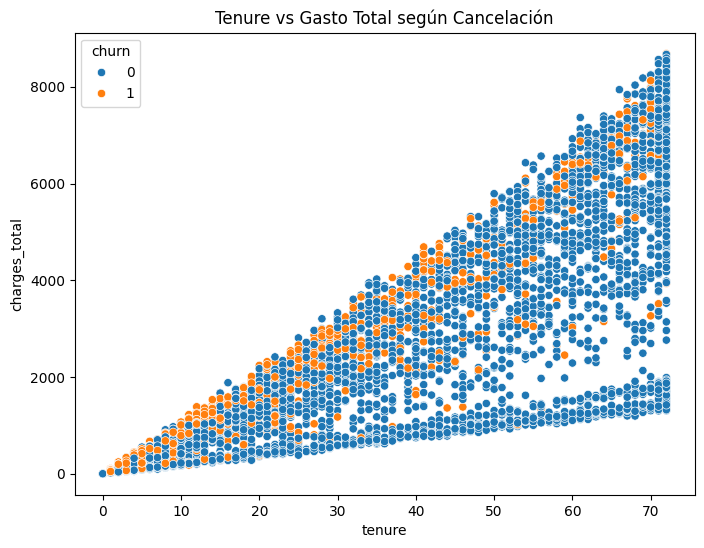

In [36]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="tenure",
    y="charges_total",
    hue="churn",
    data=df_combined
)

plt.title("Tenure vs Gasto Total según Cancelación")

plt.show()

El gráfico muestra una relación positiva entre **tenure** y **charges_total**, lo cual es esperado, ya que los clientes que permanecen más tiempo en la empresa acumulan mayor gasto total.

También se observa que los clientes que cancelan el servicio tienden a concentrarse en valores bajos de tenure y gasto total, lo que refuerza la idea de que los clientes más recientes presentan mayor riesgo de abandono.

**Tenure vs Cancelación**

El análisis muestra que los clientes que cancelan presentan, en promedio, un menor tiempo de permanencia en la empresa. Esto sugiere que los clientes nuevos tienen una mayor probabilidad de abandonar el servicio.

**Gasto total vs Cancelación**

Se observa que los clientes que cancelan tienen un menor gasto total acumulado, lo cual es consistente con su menor tiempo de permanencia en la empresa.

## Modelado predictivo

### Modelo 1: **Logistic Regression**

In [37]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train_smote)
y_pred_log = log_model.predict(X_test_scaled)

### Modelo 2: **KNN**

In [38]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train_smote)
y_pred_knn = knn_model.predict(X_test_scaled)

### Modelo 3: **Random Forest**

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42)
rf_model.fit(X_train_scaled, y_train_smote)
y_pred_rf = rf_model.predict(X_test_scaled)

### Modelo adicional: **XGBoost**

In [40]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train_scaled, y_train_smote)
y_pred_xgb = xgb_model.predict(X_test_scaled)

## Evaluacion de modelos

In [41]:
from sklearn.metrics import classification_report

In [42]:
print("***************** Logistic Regression *********************\n")
print(classification_report(y_test, y_pred_log))
print("********************** KNN ********************************\n")
print(classification_report(y_test, y_pred_knn))
print("****************** Random Forest **************************\n")
print(classification_report(y_test, y_pred_rf))
print("********************* XGBost *****************************\n")
print(classification_report(y_test, y_pred_xgb))

***************** Logistic Regression *********************

              precision    recall  f1-score   support

           0       0.87      0.82      0.85      1035
           1       0.57      0.66      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409

********************** KNN ********************************

              precision    recall  f1-score   support

           0       0.85      0.75      0.80      1035
           1       0.48      0.63      0.55       374

    accuracy                           0.72      1409
   macro avg       0.66      0.69      0.67      1409
weighted avg       0.75      0.72      0.73      1409

****************** Random Forest **************************

              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1035
           1       0.57      0.65      0.61       374


In [43]:
from sklearn.metrics import confusion_matrix

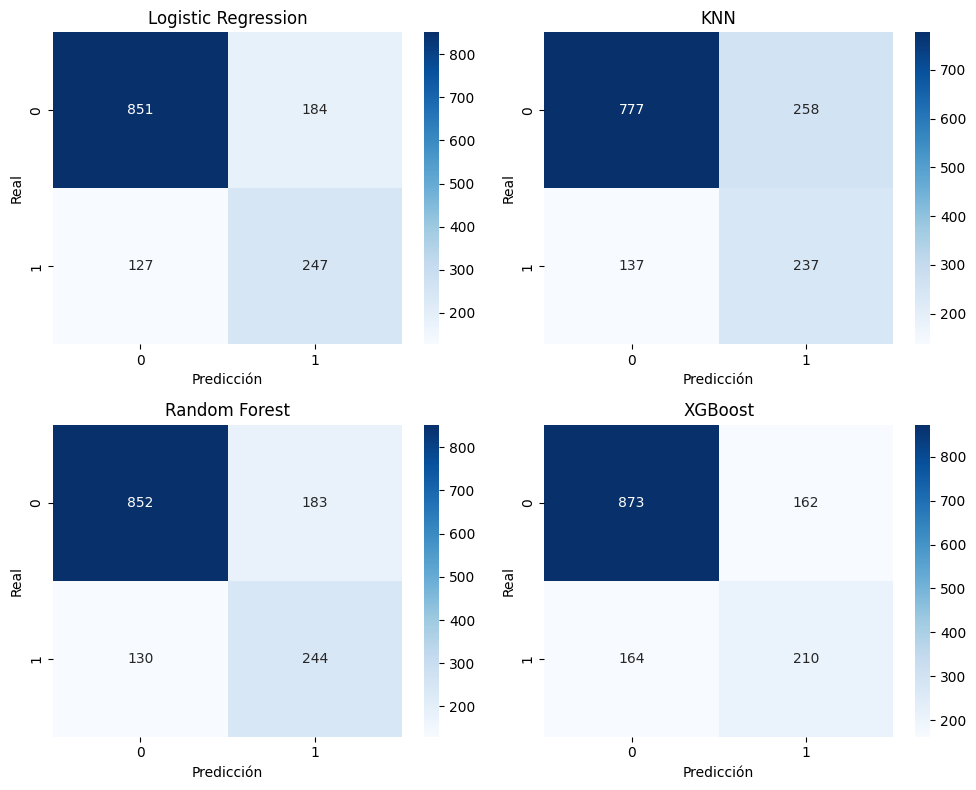

In [44]:
# Calcular matrices
cm_log = confusion_matrix(y_test, y_pred_log)
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Crear figura con 4 gráficos
fig, axes = plt.subplots(2, 2, figsize=(10,8))

# Logistic Regression
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues", ax=axes[0,0])
axes[0,0].set_title("Logistic Regression")
axes[0,0].set_xlabel("Predicción")
axes[0,0].set_ylabel("Real")

# KNN
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues", ax=axes[0,1])
axes[0,1].set_title("KNN")
axes[0,1].set_xlabel("Predicción")
axes[0,1].set_ylabel("Real")

# Random Forest
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", ax=axes[1,0])
axes[1,0].set_title("Random Forest")
axes[1,0].set_xlabel("Predicción")
axes[1,0].set_ylabel("Real")

# XGBoost
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Blues", ax=axes[1,1])
axes[1,1].set_title("XGBoost")
axes[1,1].set_xlabel("Predicción")
axes[1,1].set_ylabel("Real")

plt.tight_layout()
plt.show()

Al comparar los diferentes modelos, se observa que Logistic Regression y Random Forest presentan el mejor equilibrio entre precisión y capacidad de detección de churn.

Estos modelos permiten identificar patrones relevantes en los datos y detectar clientes con mayor probabilidad de cancelar el servicio, lo que puede ser útil para implementar estrategias de retención

## Analisis extra

Procedimos a utilizar en Logistic Regression los datos sin balancear, solo normalizados y el balanceo se dara directamente en los parametros para el entrenamiento, de la misma manera en RandomForest, observaremos si el modelo mejora o empeora al momento de evaluar el churn

In [45]:
scaler = StandardScaler()

X2_train_scaled = scaler.fit_transform(X_train)
X2_test_scaled = scaler.transform(X_test)

In [46]:
from sklearn.linear_model import LogisticRegression

log_model2 = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

log_model2.fit(X2_train_scaled, y_train)

y_pred = log_model2.predict(X2_test_scaled)

In [47]:
from sklearn.ensemble import RandomForestClassifier

rf_model2 = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=3,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42
)

rf_model2.fit(X2_train_scaled, y_train)

y_pred_rf2 = rf_model2.predict(X2_test_scaled)

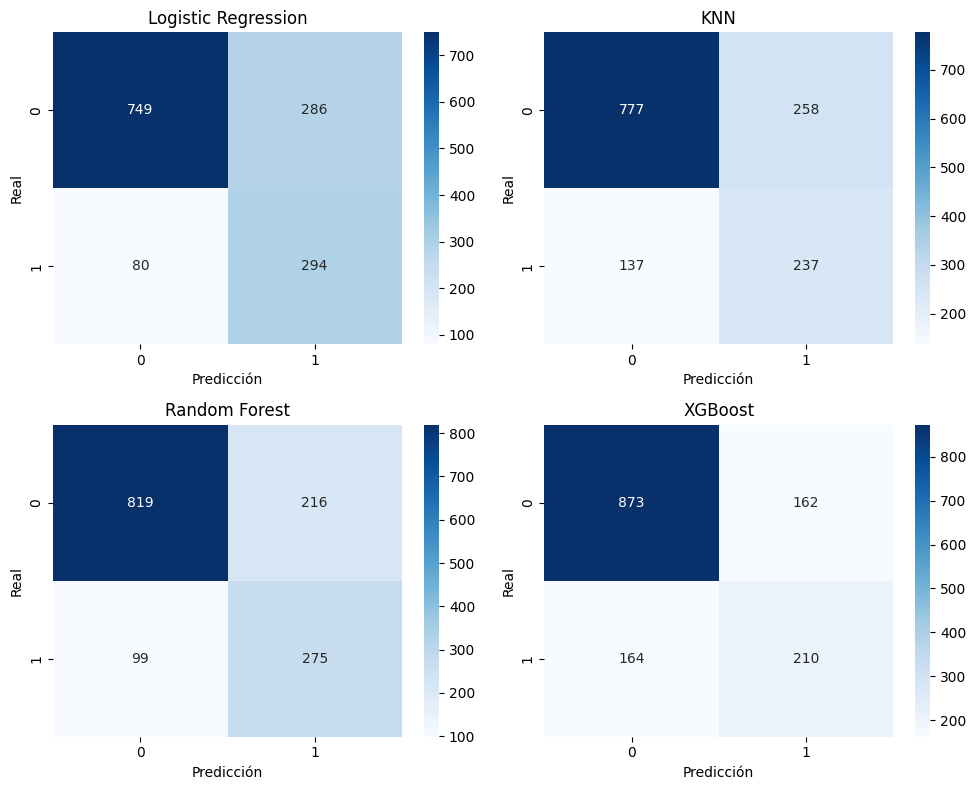

In [48]:
# Calcular matrices
cm_log = confusion_matrix(y_test, y_pred)
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_rf = confusion_matrix(y_test, y_pred_rf2)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Crear figura con 4 gráficos
fig, axes = plt.subplots(2, 2, figsize=(10,8))

# Logistic Regression
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues", ax=axes[0,0])
axes[0,0].set_title("Logistic Regression")
axes[0,0].set_xlabel("Predicción")
axes[0,0].set_ylabel("Real")

# KNN
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues", ax=axes[0,1])
axes[0,1].set_title("KNN")
axes[0,1].set_xlabel("Predicción")
axes[0,1].set_ylabel("Real")

# Random Forest
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", ax=axes[1,0])
axes[1,0].set_title("Random Forest")
axes[1,0].set_xlabel("Predicción")
axes[1,0].set_ylabel("Real")

# XGBoost
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Blues", ax=axes[1,1])
axes[1,1].set_title("XGBoost")
axes[1,1].set_xlabel("Predicción")
axes[1,1].set_ylabel("Real")

plt.tight_layout()
plt.show()

Guardemos nuestros modelos y comprobemos con un pequeño ejemplo

In [57]:
import joblib

# guardar modelos
joblib.dump(log_model2, "modelo_logistic_regression.pkl")
joblib.dump(rf_model2, "modelo_random_forest.pkl")

# guardar scaler también (MUY importante)
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [58]:
# Cargamos los modelos
log_model2 = joblib.load("modelo_logistic_regression.pkl")
rf_model2 = joblib.load("modelo_random_forest.pkl")
scaler = joblib.load("scaler.pkl")

In [59]:
# Crearemos 3 tipos de clientes para poner a prueba los modelos
clientes_prueba = pd.DataFrame([

# Cliente 1 — Alto riesgo de churn
{
'gender':1,
'seniorcitizen':1,
'partner':0,
'dependents':0,
'tenure':3,
'phoneservice':1,
'multiplelines':1,
'onlinesecurity':0,
'onlinebackup':0,
'deviceprotection':0,
'techsupport':0,
'streamingtv':1,
'streamingmovies':1,
'paperlessbilling':1,
'charges_monthly':95,
'charges_total':285,
'num_services':1,
'internetservice_Fiber optic':1,
'internetservice_No':0,
'contract_One year':0,
'contract_Two year':0,
'paymentmethod_Credit card (automatic)':0,
'paymentmethod_Electronic check':1,
'paymentmethod_Mailed check':0
},

# Cliente 2 — Muy estable
{
'gender':0,
'seniorcitizen':0,
'partner':1,
'dependents':1,
'tenure':60,
'phoneservice':1,
'multiplelines':1,
'onlinesecurity':1,
'onlinebackup':1,
'deviceprotection':1,
'techsupport':1,
'streamingtv':1,
'streamingmovies':1,
'paperlessbilling':0,
'charges_monthly':80,
'charges_total':4800,
'num_services':5,
'internetservice_Fiber optic':0,
'internetservice_No':0,
'contract_One year':0,
'contract_Two year':1,
'paymentmethod_Credit card (automatic)':1,
'paymentmethod_Electronic check':0,
'paymentmethod_Mailed check':0
},

# Cliente 3 — Riesgo medio
{
'gender':1,
'seniorcitizen':0,
'partner':0,
'dependents':0,
'tenure':18,
'phoneservice':1,
'multiplelines':0,
'onlinesecurity':0,
'onlinebackup':1,
'deviceprotection':0,
'techsupport':0,
'streamingtv':0,
'streamingmovies':1,
'paperlessbilling':1,
'charges_monthly':65,
'charges_total':1170,
'num_services':2,
'internetservice_Fiber optic':1,
'internetservice_No':0,
'contract_One year':1,
'contract_Two year':0,
'paymentmethod_Credit card (automatic)':0,
'paymentmethod_Electronic check':1,
'paymentmethod_Mailed check':0
}

])

In [60]:
clientes_scaled = scaler.transform(clientes_prueba)

In [62]:
pred_lr = log_model2.predict(clientes_scaled)
prob_lr = log_model2.predict_proba(clientes_scaled)

print("Predicciones LR:", pred_lr)
print("Probabilidades LR:")
print(prob_lr)

Predicciones LR: [1 0 1]
Probabilidades LR:
[[0.06953887 0.93046113]
 [0.95880153 0.04119847]
 [0.29327173 0.70672827]]


In [63]:
pred_rf = rf_model2.predict(clientes_scaled)
prob_rf = rf_model2.predict_proba(clientes_scaled)

print("Predicciones RF:", pred_rf)
print("Probabilidades RF:")
print(prob_rf)

Predicciones RF: [1 0 0]
Probabilidades RF:
[[0.0897871  0.9102129 ]
 [0.97150833 0.02849167]
 [0.63302041 0.36697959]]


In [65]:
resultados = pd.DataFrame({
'Cliente':[1,2,3],
'Pred_LR':pred_lr,
'Pred_RF':pred_rf,
'Prob_Churn_LR':prob_lr[:,1],
'Prob_Churn_RF':prob_rf[:,1]
})

resultados

,Cliente,Pred_LR,Pred_RF,Prob_Churn_LR,Prob_Churn_RF
0,1,1,1,0.930461,0.910213
1,2,0,0,0.041198,0.028492
2,3,1,0,0.706728,0.366980


Para validar el comportamiento de los modelos entrenados, se realizaron predicciones sobre tres clientes simulados con diferentes perfiles. Los resultados muestran que ambos modelos logran identificar correctamente casos extremos de churn y de permanencia del cliente.

En el caso de clientes con alto riesgo de cancelación o clientes claramente fidelizados, ambos modelos coinciden en sus predicciones. Sin embargo, en perfiles intermedios pueden presentarse diferencias entre modelos, lo cual es normal en problemas de clasificación.

Este ejercicio demuestra que los modelos desarrollados son capaces de evaluar nuevos clientes y estimar su probabilidad de cancelación, lo cual puede ser utilizado como una herramienta de apoyo para la toma de decisiones y la implementación de estrategias de retención.

## Importancia de variables

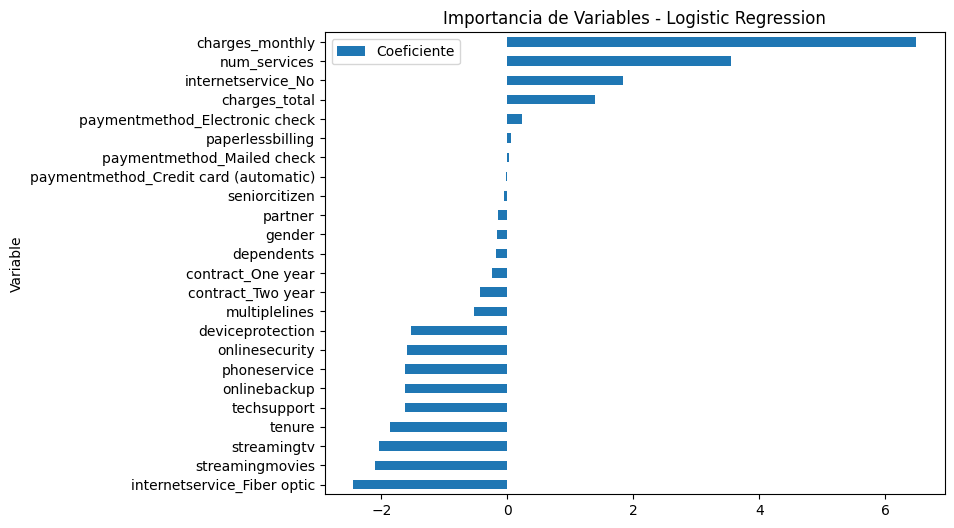

In [49]:
coef = log_model.coef_[0]

importance_lr = pd.DataFrame({
    "Variable": X_train.columns,
    "Coeficiente": coef
})

importance_lr = importance_lr.sort_values("Coeficiente")

importance_lr.plot.barh(x="Variable", y="Coeficiente", figsize=(8,6))
plt.title("Importancia de Variables - Logistic Regression")
plt.show()

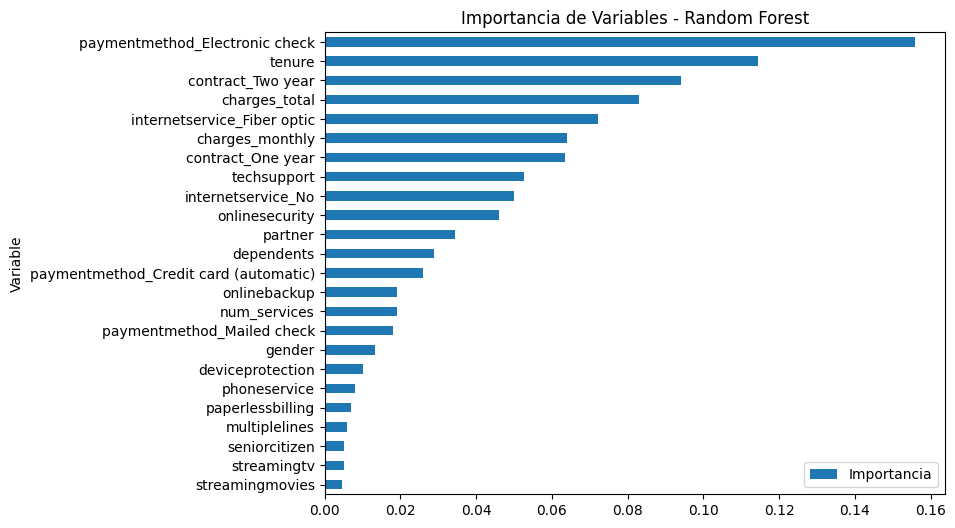

In [50]:
importances = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": importances
})

feature_importance = feature_importance.sort_values("Importancia", ascending=True)

feature_importance.plot.barh(x="Variable", y="Importancia", figsize=(8,6))
plt.title("Importancia de Variables - Random Forest")
plt.show()

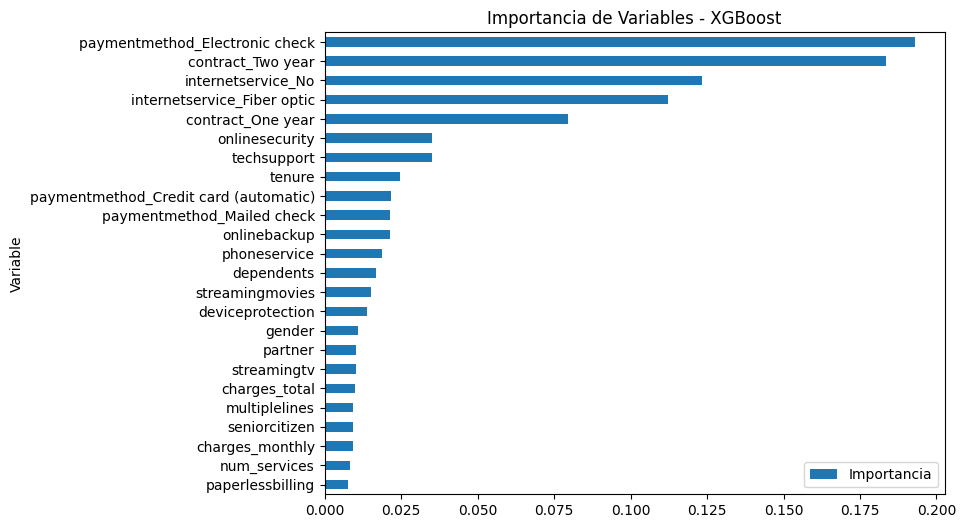

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

importances = xgb_model.feature_importances_

importance_xgb = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": importances
})

importance_xgb = importance_xgb.sort_values("Importancia")

importance_xgb.plot.barh(x="Variable", y="Importancia", figsize=(8,6))
plt.title("Importancia de Variables - XGBoost")
plt.show()

In [52]:
models = {
    'LR': log_model,
    'KNN': knn_model,
    'RF': rf_model,
    'XGB': xgb_model
}

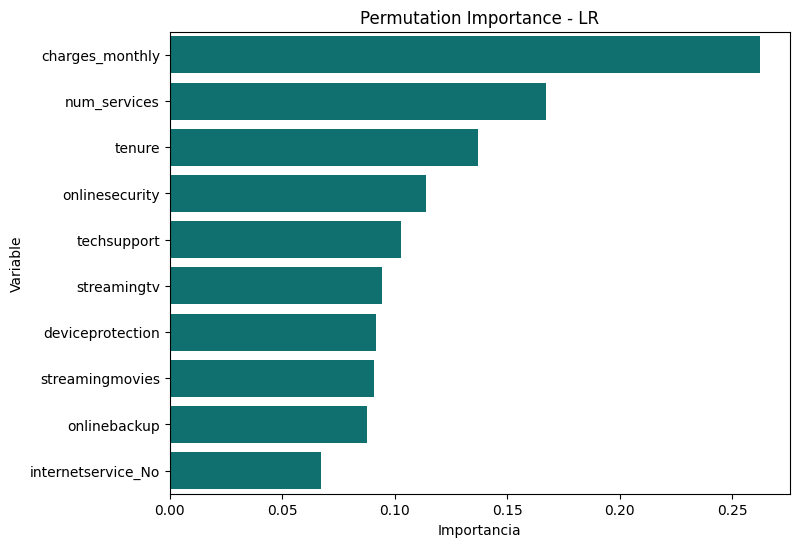

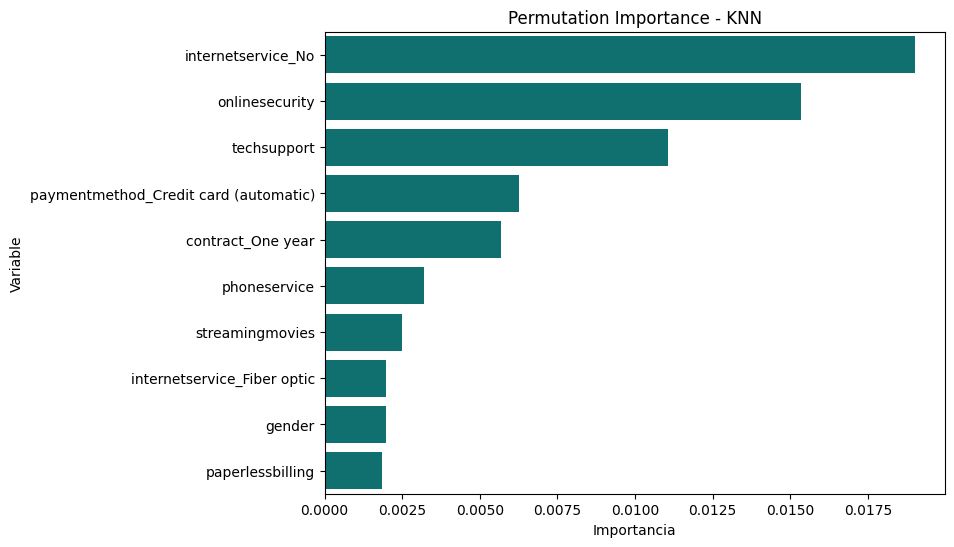

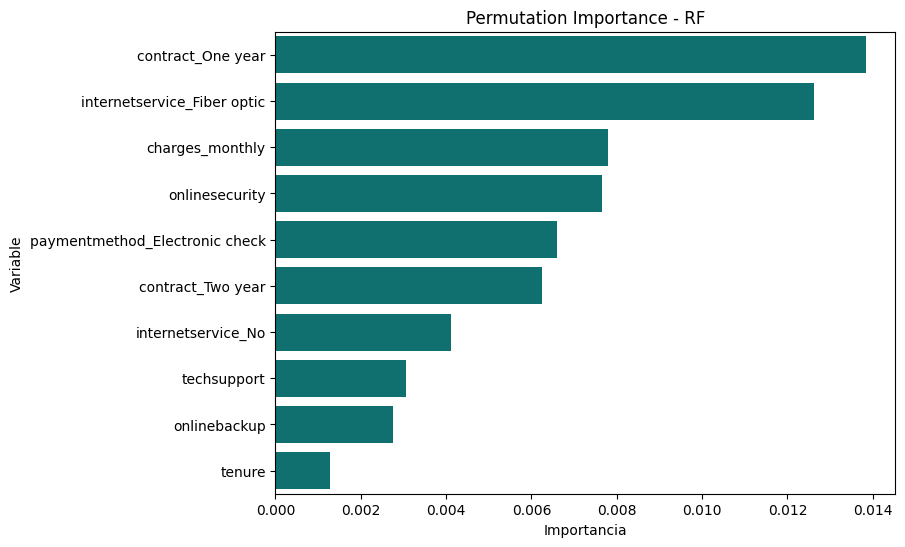

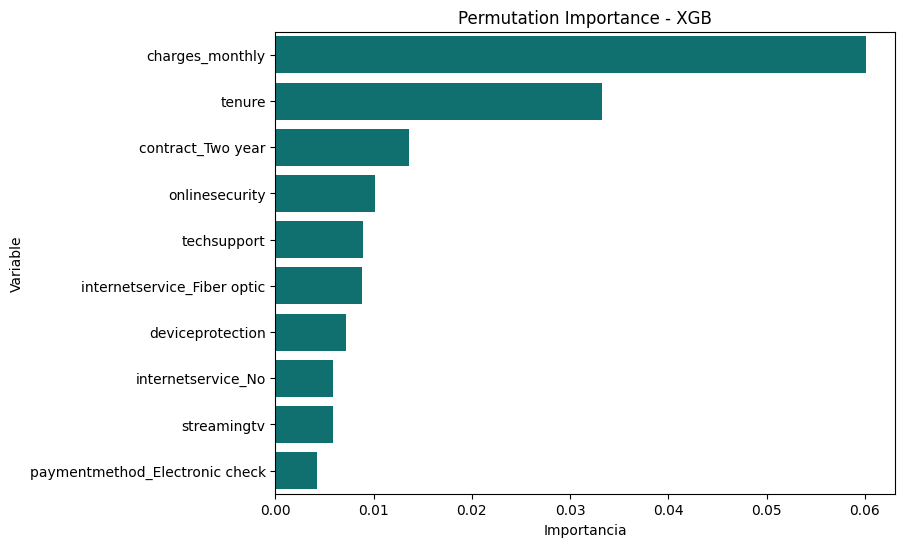

In [56]:
from sklearn.inspection import permutation_importance

for name, model in models.items():

    if name in ['LR','KNN']:
        X_data = X_test_scaled
    else:
        X_data = X_test_scaled

    result = permutation_importance(
        model,
        X_data,
        y_test,
        n_repeats=10,
        random_state=42,
        n_jobs=-1
    )

    importance_df = pd.DataFrame({
        "Variable": X_train.columns,
        "Importancia": result.importances_mean
    }).sort_values("Importancia", ascending=False)

    plt.figure(figsize=(8,6))
    sns.barplot(
        data=importance_df.head(10),
        x="Importancia",
        y="Variable",
        color="teal"
    )

    plt.title(f"Permutation Importance - {name}")
    plt.show()

Al comparar la importancia de variables entre los distintos modelos, se observa consistencia en algunos factores clave que influyen en la cancelación de clientes.

Entre las variables más recurrentes destacan:

- Tenure (antigüedad del cliente)

- Charges_monthly (cargo mensual)

- Tipo de contrato

- Tipo de servicio de internet

- Cantidad de servicios adicionales

Estas variables aparecen repetidamente como importantes en varios modelos, lo que sugiere que tienen una influencia significativa en la probabilidad de churn.

## Conclusión

El objetivo de este análisis fue desarrollar modelos predictivos capaces de identificar clientes con mayor probabilidad de cancelar el servicio (churn) en la empresa Telecom X. Para ello se realizó un proceso completo de preparación de datos, análisis exploratorio, ingeniería de variables, entrenamiento de múltiples modelos de clasificación y evaluación de su desempeño.

Durante el análisis exploratorio se identificó que la variable objetivo presenta un desbalance moderado, con aproximadamente un 73% de clientes que permanecen en la empresa y un 27% que cancelan el servicio. Para mejorar la capacidad del modelo de detectar clientes con riesgo de churn, se aplicó la técnica de balanceo **SMOTE**, permitiendo equilibrar ambas clases durante el entrenamiento.

El análisis de correlación y las visualizaciones exploratorias permitieron identificar varios factores asociados a la cancelación de clientes. Entre los más relevantes destacan el tiempo de permanencia del cliente **(tenure)**, el cargo mensual del servicio **(charges_monthly)**, el tipo de contrato, el tipo de servicio de internet y la cantidad de servicios adicionales contratados.

Los resultados muestran que los clientes con menor antigüedad en la empresa presentan una mayor probabilidad de cancelar el servicio, lo que indica que los primeros meses de relación con el cliente son un período crítico para su retención. Asimismo, se observó que los clientes con mayores cargos mensuales tienden a cancelar con mayor frecuencia, lo que podría reflejar una percepción de alto costo en relación con el valor del servicio recibido.

Otro factor importante identificado fue el tipo de contrato. Los clientes con contratos de mayor duración, como los contratos de dos años, presentan una probabilidad significativamente menor de cancelar el servicio en comparación con aquellos con contratos mensuales. Esto sugiere que los contratos a largo plazo contribuyen a una mayor fidelización de los clientes.

En cuanto al modelado predictivo, se evaluaron distintos algoritmos de clasificación como **Logistic Regression, K-Nearest Neighbors, Random Forest y XGBoost.**

Los resultados mostraron que **Logistic Regression y Random Forest** ofrecieron el mejor equilibrio entre precisión y capacidad de detección de clientes que cancelan el servicio, logrando un desempeño competitivo en términos de accuracy, precision y recall. Estos modelos demostraron ser efectivos para identificar patrones relevantes en los datos y predecir el comportamiento de cancelación.

El análisis de importancia de variables confirmó que **tenure, charges_monthly, tipo de contrato, tipo de servicio de internet y número de servicios adicionales** son algunos de los factores más influyentes en la predicción del churn.

A partir de los resultados obtenidos, se pueden plantear diversas estrategias para reducir la cancelación de clientes:

1. **Fortalecer la fidelización de nuevos clientes:** Dado que los clientes con menor antigüedad presentan mayor riesgo de cancelación, es recomendable implementar programas de acompañamiento durante los primeros meses, como promociones, seguimiento personalizado o beneficios de bienvenida.

2. **Revisar la estructura de precios o el valor percibido del servicio:** Los resultados sugieren que cargos mensuales elevados pueden estar asociados a mayor probabilidad de cancelación. La empresa podría evaluar ajustes en los planes o mejorar la percepción de valor mediante beneficios adicionales.

3. **Incentivar contratos de mayor duración:** Promover contratos anuales o de dos años mediante descuentos, promociones o beneficios exclusivos puede ayudar a aumentar la permanencia de los clientes.

4. **Promover la contratación de servicios adicionales:**
Se observó que los clientes con mayor número de servicios contratados presentan menor probabilidad de cancelar el servicio. La empresa podría fomentar paquetes de servicios integrados que aumenten el compromiso del cliente con la compañía.